# Handwritten Digit Recognition using Classical Machine Learning

**Assignment:** Virutalyyst – AI Engineer  
**Author:** Mehtab Singh  
**Dataset:** MNIST (CSV Format)  

---

## Objective

The objective of this assignment is to design and evaluate a complete machine learning pipeline for classifying handwritten digits (0–9) using **classical machine learning algorithms**.

The focus is not only on achieving good accuracy, but also on:
- Data understanding
- Correct preprocessing
- Model selection rationale
- Error analysis
- Clear and explainable results

All solutions strictly follow the given constraints:
- No deep learning
- No pre-trained models
- Only classical ML techniques
assical ML techniques


## Dataset Description

The dataset used is a CSV-based subset of the MNIST handwritten digit dataset.

Each row represents one grayscale image:
- `label` → digit (0–9)
- `pixel0` to `pixel783` → flattened 28×28 pixel intensities (0–255)

Two separate files are used:
- `mnist_train.csv` for training
- `mnist_test.csv` for evaluation

Using a predefined train–test split avoids data leakage and mirrors real-world ML evaluation practices.


## Technical Flow Diagram of Execution

The following diagram represents the complete execution pipeline of the assignment:

```
MNIST CSV Dataset
(mnist_train.csv, mnist_test.csv)
        |
        v
Data Loading
(Read CSV files using Pandas)
        |
        v
Data Exploration
- Dataset shape
- Class distribution
- Sample image visualization
        |
        v
Data Preprocessing
- Pixel normalization (0–1)
- Feature and label separation
        |
        v
Dimensionality Reduction (Optional)
- PCA for noise reduction and efficiency
        |
        v
Model Training
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Decision Tree
        |
        v
Model Evaluation
- Accuracy calculation
- Confusion matrix visualization
        |
        v
Misclassification Analysis
- Visual inspection of incorrect predictions
        |
        v
From-Scratch Model Implementation
- Manual KNN (distance calculation + voting)
        |
        v
Final Comparison and Reporting
- Model comparison
- Observations and conclusions
```



In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA


In [49]:
train_path = r"C:\Users\Asus\OneDrive\Desktop\Virtualyyst\mnist_train.csv"
test_path  = r"C:\Users\Asus\OneDrive\Desktop\Virtualyyst\mnist_test.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)


Train Shape: (60000, 785)
Test Shape: (10000, 785)


## Data Exploration

Before training any model, the dataset is explored to:
- Verify data integrity
- Check class distribution
- Ensure images are loaded correctly

This step helps avoid incorrect assumptions that could affect model performance.


In [52]:
train_df['label'].value_counts().sort_index()


label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

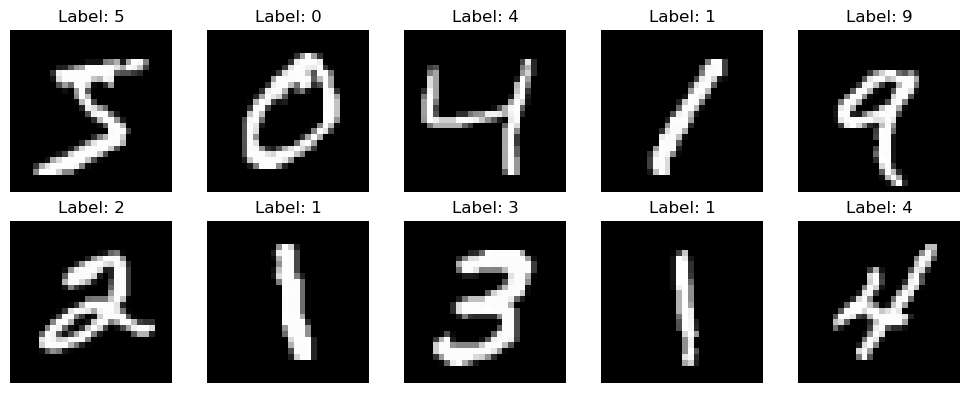

In [54]:
fig, axes = plt.subplots(2, 5, figsize=(10,4))

for i, ax in enumerate(axes.flat):
    image = train_df.iloc[i, 1:].values.reshape(28,28)
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Label: {train_df.iloc[i,0]}")
    ax.axis('off')

plt.tight_layout()
plt.show()


## Data Preprocessing

Pixel values range from 0 to 255.
Since distance-based (KNN) and margin-based (SVM) models are sensitive to feature scale,
all pixel values are normalized to the range [0, 1].

 

In [60]:
X_train = train_df.iloc[:, 1:].values / 255.0
y_train = train_df.iloc[:, 0].values

X_test  = test_df.iloc[:, 1:].values / 255.0
y_test  = test_df.iloc[:, 0].values


## Dimensionality Reduction using PCA

Principal Component Analysis (PCA) is applied to reduce dimensionality and noise.
This is especially useful for SVM, which can be computationally expensive in high-dimensional spaces.


In [65]:
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print("Explained Variance:", np.sum(pca.explained_variance_ratio_))


Explained Variance: 0.8246468633334724


## Model Selection Rationale

Three classical machine learning models are evaluated:

1. **K-Nearest Neighbors (KNN)**  
   A strong non-parametric baseline that performs well on image-like data but scales poorly.

2. **Support Vector Machine (SVM)**  
   Effective in high-dimensional spaces and offers strong generalization through margin maximization.

3. **Decision Tree**  
   Provides interpretability but is prone to overfitting on pixel-level noise.


In [68]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_preds = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_preds)

print("KNN Accuracy:", knn_acc)


KNN Accuracy: 0.9688


In [70]:
svm = SVC(kernel='rbf', C=10, gamma=0.01)
svm.fit(X_train_pca, y_train)

svm_preds = svm.predict(X_test_pca)
svm_acc = accuracy_score(y_test, svm_preds)

print("SVM Accuracy:", svm_acc)


SVM Accuracy: 0.9852


In [71]:
dt = DecisionTreeClassifier(max_depth=20, min_samples_split=5)
dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)

print("Decision Tree Accuracy:", dt_acc)


Decision Tree Accuracy: 0.8802


## Model Evaluation

Accuracy provides an overall comparison, while confusion matrices reveal digit-wise error patterns.


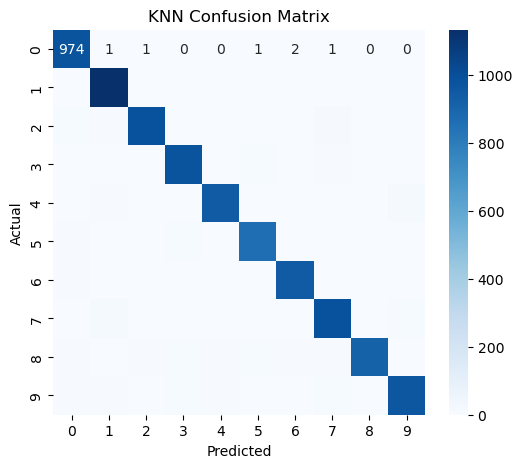

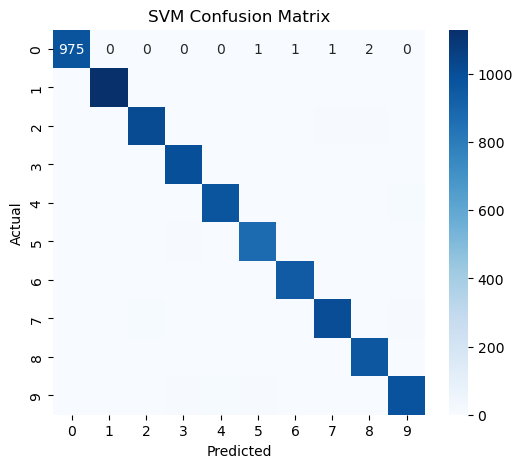

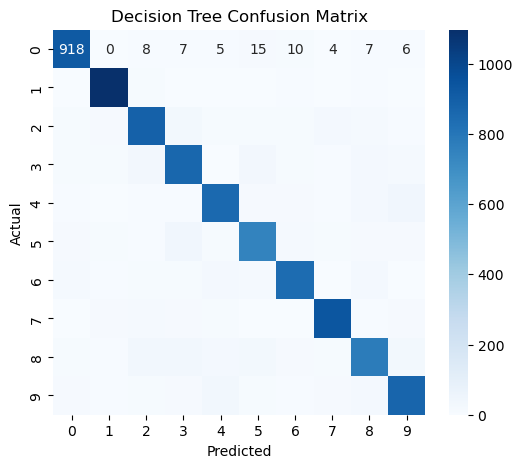

In [75]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion(y_test, knn_preds, "KNN Confusion Matrix")
plot_confusion(y_test, svm_preds, "SVM Confusion Matrix")
plot_confusion(y_test, dt_preds,  "Decision Tree Confusion Matrix")


## Misclassification Analysis

Misclassified samples are visualized to understand common error patterns.
Most errors occur between visually similar digits.


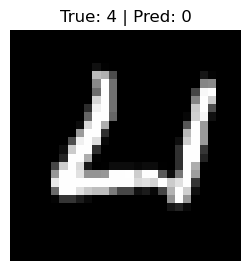

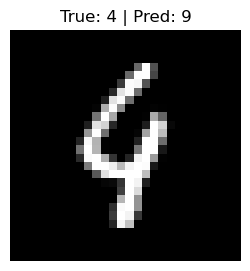

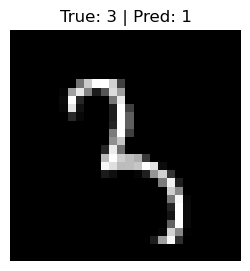

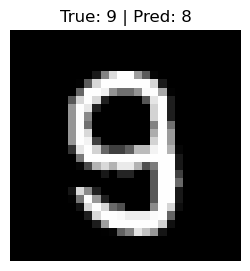

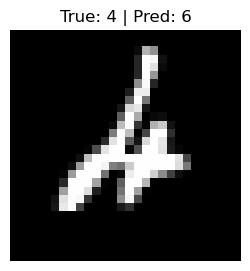

In [80]:
wrong_idx = np.where(knn_preds != y_test)[0][:5]

for idx in wrong_idx:
    plt.figure(figsize=(3,3))   # NEW figure for each image
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"True: {y_test[idx]} | Pred: {knn_preds[idx]}")
    plt.axis('off')
    plt.show()


## K-Nearest Neighbors from Scratch

To demonstrate algorithmic understanding, KNN is implemented manually without using
any machine learning library.


In [83]:
from collections import Counter

def knn_from_scratch(X_train, y_train, x_test, k=5):
    distances = []
    for i in range(len(X_train)):
        dist = np.linalg.norm(X_train[i] - x_test)
        distances.append((dist, y_train[i]))
    distances.sort(key=lambda x: x[0])
    neighbors = [label for _, label in distances[:k]]
    return Counter(neighbors).most_common(1)[0][0]

for i in range(3):
    pred = knn_from_scratch(X_train[:1000], y_train[:1000], X_test[i], k=5)
    print(f"True: {y_test[i]}, Predicted: {pred}")


True: 7, Predicted: 7
True: 2, Predicted: 2
True: 1, Predicted: 1


## Final Model Comparison


In [86]:
results = pd.DataFrame({
    "Model": ["KNN", "SVM", "Decision Tree"],
    "Accuracy": [knn_acc, svm_acc, dt_acc]
})

results


,Model,Accuracy
0,KNN,0.9688
1,SVM,0.9852
2,Decision Tree,0.8802


## Final Observations and Conclusion

Among the evaluated models, Support Vector Machine (SVM) achieved the highest accuracy due to its robustness in high-dimensional feature spaces and effective margin-based learning. K-Nearest Neighbors performed competitively as a baseline but showed scalability limitations during inference. Decision Trees offered interpretability but were more prone to overfitting on pixel-level noise.

Misclassification analysis revealed errors mainly between visually similar digits such as 3 and 5 or 4 and 9, highlighting the limitations of raw pixel features. Performance could be improved through dimensionality reduction, better feature engineering, or ensemble methods while still adhering to classical machine learning constraints.

Overall, this assignment demonstrates a complete, interpretable, and production-aware machine learning pipeline.
